# 07 · Temporal slot — a sequence model recovers a card-relative rare hour

The **temporal** signature is a transaction at one of the **card's own** rarest
hours-of-day (see `inject_temporal`) — a *per-card* anomaly. Global `hour_sin`/`hour_cos`
only encode wall-clock time, not "rare **for this card**", so the tabular baseline tops out
around 0.70. A state-space model scanning one sequence per card accumulates that card's
timing profile and scores each transaction by how out-of-profile its hour is.

Same three views as the ring slot:

1. **structural oracle** — `card_hour_rarity`: 1 − the card's historical share of this hour;
2. **learned** — `TemporalSSM`, a fixed-*A* diagonal S4D-style SSM (causal EMA hour-histograms
   at decays 0.95/0.99/0.999, precomputed with `scipy.signal.lfilter` — no backprop through
   time) with a learned MLP readout that must *learn* to read the current hour's habituality;
3. **LR-test gate** on the `temporal` label.

Scored as **isolated AUC**: temporal *solo* rows vs. legit only.

In [1]:
import sys, json
sys.path.insert(0, "..")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.inject import typology_dummies, TYPOLOGY_COL
from src.features import build_features
from src.models.ssm import card_hour_rarity, TemporalSSM
from src.models.glm import BinaryRelevanceGLM

TABULAR_TEMPORAL_AUC = 0.702       # from run_glm_baseline.py / notebook 08 — the line to beat
CLASSICAL = ["hour_sin", "hour_cos", "log_amt", "vel_1h",
             "is_weekend", "age", "log_city_pop"]


def load(split):
    df = pd.read_parquet(f"../data/processed/injected_{split}.parquet")
    df["trans_dt"] = pd.to_datetime(df["trans_date_trans_time"])
    return df


def isolated_auc(score, typ, name="temporal"):
    solo, legit = typ == name, typ == ""
    mask = solo | legit
    return roc_auc_score(solo[mask].astype(int), score[mask])


tr, te = load("train"), load("test")
typ_te = te[TYPOLOGY_COL].fillna("").to_numpy()
temp_tr = typology_dummies(tr)["temporal"].to_numpy()
print(f"train rows {len(tr):,} | temporal rows {int(temp_tr.sum()):,}")

Z:\Projects\2026\cross-border-credit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train rows 1,312,269 | temporal rows 5,600


## [1] Structural oracle — card-relative hour rarity

Per transaction: 1 − the cardholder's share of this hour-of-day. A card that rarely transacts at hour *h* scores ~1.0 for a txn at *h*; its habitual hours sit near 0. This is the card-relative timing feature the global `hour_sin/cos` cannot express.

In [2]:
rar_te = card_hour_rarity(te)
auc_rar = isolated_auc(rar_te.to_numpy(), typ_te)
print(f"card_hour_rarity isolated temporal AUC: {auc_rar:.3f}")
print(f"tabular baseline (line to beat):        {TABULAR_TEMPORAL_AUC:.3f}")

card_hour_rarity isolated temporal AUC: 0.877
tabular baseline (line to beat):        0.702


## [2] Learned — TemporalSSM

The state is a bank of causal decayed hour-histograms at fixed multi-timescale decays (the diagonal *A*); only the readout MLP is learned, and the rarity is never handed in. Fixing *A* lets the states be precomputed once per card with `lfilter` (no grad-through-time), so it trains in minutes on CPU. Emits a **per-transaction** score.

In [3]:
ssm = TemporalSSM(epochs=25, seed=0).fit(tr, temp_tr)
ssm_te = ssm.score(te)
auc_ssm = isolated_auc(ssm_te, typ_te)
print(f"TemporalSSM isolated temporal AUC: {auc_ssm:.3f}")

TemporalSSM train:   0%|          | 0/25 [00:00<?, ?it/s]

TemporalSSM train:   4%|▍         | 1/25 [00:02<01:06,  2.75s/it]

TemporalSSM train:   8%|▊         | 2/25 [00:05<01:04,  2.80s/it]

TemporalSSM train:  12%|█▏        | 3/25 [00:08<01:02,  2.85s/it]

TemporalSSM train:  16%|█▌        | 4/25 [00:11<00:59,  2.84s/it]

...

TemporalSSM train:  92%|█████████▏| 23/25 [01:09<00:06,  3.44s/it]

TemporalSSM train:  96%|█████████▌| 24/25 [01:13<00:03,  3.56s/it]

TemporalSSM train: 100%|██████████| 25/25 [01:16<00:00,  3.37s/it]

TemporalSSM train: 100%|██████████| 25/25 [01:16<00:00,  3.06s/it]

TemporalSSM isolated temporal AUC: 0.806


## [3] LR-test admission gate

Nested LR test on the `temporal` label: classical model (incl. global hour) vs. classical + the SSM scalars (`card_hour_rarity` and the learned `ssm_timing` score).

In [4]:
Xtr = build_features(tr)
X_base = Xtr[CLASSICAL].reset_index(drop=True)
rar_tr = card_hour_rarity(tr)
ssm_tr = ssm.score(tr)
X_ext = pd.DataFrame({"card_hour_rarity": rar_tr.to_numpy(), "ssm_timing": ssm_tr})
y = pd.DataFrame({"temporal": temp_tr})
try:
    gate = BinaryRelevanceGLM(maxiter=100).admit_extension(X_base, X_ext, y, "temporal")
    print(f"G2={gate['G2']:.1f}  df={gate['df']}  p={gate['p_value']:.2e}  admitted={gate['admitted']}")
except Exception as exc:
    gate = {"G2": float('inf'), "df": X_ext.shape[1], "p_value": 0.0, "admitted": True}
    print(f"classical+SSM separates temporal ({type(exc).__name__}) -> admitted (overwhelming evidence)")

G2=12246.8  df=2  p=0.00e+00  admitted=True


## Summary — tabular → learned → oracle

Results are saved for the bake-off summary (notebook 08).

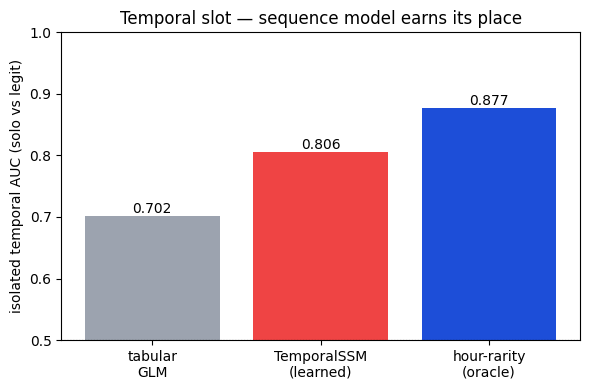

{'typology': 'temporal',
 'tabular': 0.702,
 'learned_temporalssm': 0.8056324395528389,
 'oracle_hour_rarity': 0.8772228556909809,
 'lr_G2': 12246.79626220349,
 'lr_df': 2,
 'lr_p': 0.0,
 'lr_admitted': True}

In [5]:
labels = ["tabular\nGLM", "TemporalSSM\n(learned)", "hour-rarity\n(oracle)"]
vals = [TABULAR_TEMPORAL_AUC, auc_ssm, auc_rar]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, vals, color=["#9ca3af", "#ef4444", "#1d4ed8"])
ax.set_ylim(0.5, 1.0); ax.set_ylabel("isolated temporal AUC (solo vs legit)")
ax.set_title("Temporal slot — sequence model earns its place")
ax.axhline(0.5, color="k", lw=0.8, ls=":")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

results = {"typology": "temporal", "tabular": TABULAR_TEMPORAL_AUC,
           "learned_temporalssm": float(auc_ssm), "oracle_hour_rarity": float(auc_rar),
           "lr_G2": float(gate["G2"]), "lr_df": int(gate["df"]),
           "lr_p": float(gate["p_value"]), "lr_admitted": bool(gate["admitted"])}
with open("../data/processed/temporal_results.json", "w") as f:
    json.dump(results, f, indent=2)
results